In [ ]:
# ================================
# KUCOGNITION NLP INTENT CLASSIFIER
# Google Colab Training Script
# ================================

!pip install scikit-learn nltk pandas

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK resources
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
# nltk.download('punkt_tab')

from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import pickle

# ================================
# 1. UPLOAD CSV
# ================================
from google.colab import files
print("Upload your kubot dataset file...")
uploaded = files.upload()

df = pd.read_csv("kubot_intent_dataset.csv")
df.head()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Upload your kubot dataset file...


Saving kubot_intent_dataset.csv to kubot_intent_dataset.csv


,text,intent
0,hi kubot,greeting_smalltalk
1,hello,greeting_smalltalk
2,hey there,greeting_smalltalk
3,good morning kubot,greeting_smalltalk
4,good evening,greeting_smalltalk


In [ ]:
# ======================================================
# CHECK CLASS DISTRIBUTION
# ======================================================

print("Total samples:", len(df))

print("\nSamples per class:")
class_counts = df['intent'].value_counts()
print(class_counts)

print("\nPercentage per class:")
print((class_counts / len(df)) * 100)

Total samples: 727

Samples per class:
intent
faq_treatment          94
farewell               92
emotion_support        90
greeting_smalltalk     89
faq_capabilities       89
app_navigation         89
nail_condition_info    89
faq_accuracy           88
Name: count, dtype: int64

Percentage per class:
intent
faq_treatment          12.929849
farewell               12.654746
emotion_support        12.379642
greeting_smalltalk     12.242091
faq_capabilities       12.242091
app_navigation         12.242091
nail_condition_info    12.242091
faq_accuracy           12.104539
Name: count, dtype: float64


In [ ]:
# ================================
# 2. TEXT PREPROCESSING
# ================================

def preprocess(text):
    # make sure it's a string
    text = str(text)
    # lowercase only, keep punctuation and structure
    text = text.lower()
    # collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['text'].apply(preprocess)
df.head()


,text,intent,clean_text
0,hi kubot,greeting_smalltalk,hi kubot
1,hello,greeting_smalltalk,hello
2,hey there,greeting_smalltalk,hey there
3,good morning kubot,greeting_smalltalk,good morning kubot
4,good evening,greeting_smalltalk,good evening


In [ ]:
# Make sure there are no missing texts or labels
df = df.dropna(subset=["clean_text", "intent"]).copy()

# (optional) force to string, in case some values are not
df["clean_text"] = df["clean_text"].astype(str)
df["intent"] = df["intent"].astype(str)


In [ ]:
# ================================
# 3. TF-IDF VECTORIZATION
# ================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.svm import LinearSVC

vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),   # unigrams + bigrams + trigrams
    min_df=1,
    max_features=None,
    sublinear_tf=True
)

X = vectorizer.fit_transform(df['clean_text'])
y = df['intent']

# ================================
# 4. TRAIN / TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,       # 10% test
    random_state=42,
    stratify=y
)

# ================================
# 5. TRAIN LINEAR SVM (LinearSVC)
# ================================
model = LinearSVC(
    C=4.0   # 🔁 was 2.0, now a bit less regularization
)
model.fit(X_train, y_train)

# ================================
# 6. EVALUATE
# ================================
preds = model.predict(X_test)

acc = accuracy_score(y_test, preds)
macro_f1 = f1_score(y_test, preds, average="macro")

print("\nAccuracy:", acc)
print("Macro F1-score:", macro_f1)
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

# ================================
# 7. CONFUSION MATRIX + MISCLASSIFIED EXPORT
# ================================
labels = sorted(y.unique())
cm = confusion_matrix(y_test, preds, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{l}" for l in labels],
    columns=[f"pred_{l}" for l in labels]
)

print("\nConfusion Matrix (rows = true, cols = pred):\n")
print(cm_df)

test_texts = df.loc[y_test.index, "text"]
test_clean = df.loc[y_test.index, "clean_text"]

misclassified = pd.DataFrame({
    "text": list(test_texts),
    "clean_text": list(test_clean),
    "true": list(y_test),
    "pred": list(preds)
})
misclassified = misclassified[misclassified["true"] != misclassified["pred"]]

print(f"\nNumber of misclassified samples: {len(misclassified)}")
misclassified.to_csv("misclassified_intents.csv", index=False)
print("Saved misclassified samples to misclassified_intents.csv")



Accuracy: 0.9444444444444444
Macro F1-score: 0.9427244582043344

Classification Report:

                     precision    recall  f1-score   support

     app_navigation       0.88      0.78      0.82         9
    emotion_support       1.00      1.00      1.00         9
       faq_accuracy       0.90      1.00      0.95         9
   faq_capabilities       0.90      1.00      0.95         9
      faq_treatment       0.88      0.78      0.82         9
           farewell       1.00      1.00      1.00         9
 greeting_smalltalk       1.00      1.00      1.00         9
nail_condition_info       1.00      1.00      1.00         9

           accuracy                           0.94        72
          macro avg       0.94      0.94      0.94        72
       weighted avg       0.94      0.94      0.94        72


Confusion Matrix (rows = true, cols = pred):

                          pred_app_navigation  pred_emotion_support  \
true_app_navigation                         7            

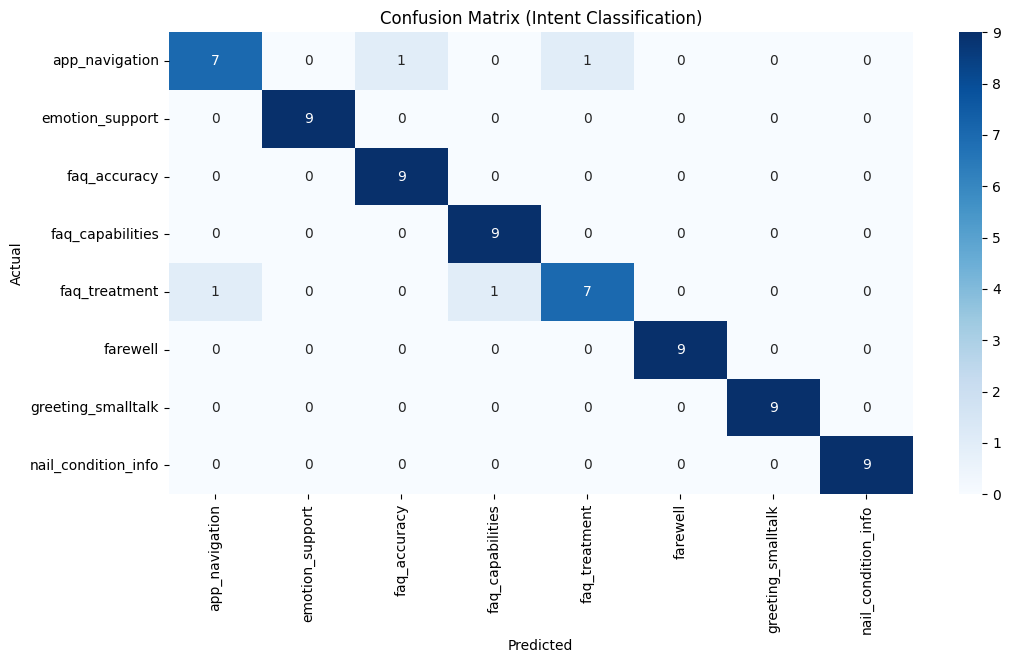

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix (Intent Classification)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
import joblib

joblib.dump(model, "nail_symptom_model_svc.joblib")
joblib.dump(vectorizer, "nail_symptom_tfidf_vectorizer.joblib")

print("Saved intent model and vectorizer.")

Saved intent model and vectorizer.


In [ ]:
from google.colab import files

files.download("nail_symptom_model_svc.joblib")
files.download("nail_symptom_tfidf_vectorizer.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>